# Classificação de Risco Ambiental em Propriedades Agrícolas

## Integrantes:
- Felipe Hui Hattori - RM565169
- Kauany Ribeiro de Moura - RM564576
- Lucas Kenzo Nishiwaki - RM561325

## Objetivo
Classificar propriedades agrícolas em **baixo risco (0)** ou **alto risco ambiental (1)** utilizando técnicas de Ciência de Dados e Machine Learning.

### Regra de negócio da variável alvo
A variável **RISCO_AMBIENTAL** será considerada de alto risco quando a propriedade apresentar combinação de:
- Alto consumo de água;
- Alto uso de pesticidas;
- Alto uso de fertilizantes;
- Baixa produtividade.

Como o dataset já possui a coluna `RISCO_AMBIENTAL`, será utilizada como variável target do modelo.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)


## Etapa 2 - Carregamento e compreensão inicial dos dados

In [2]:

df = pd.read_csv('dataset_agricultura_orbital.csv')

print('Quantidade de linhas e colunas:', df.shape)

display(df.head())
display(df.info())
display(df.describe(include='all'))

print('\nValores Missing:')
print(df.isnull().sum())

numericas = df.select_dtypes(include=np.number).columns.tolist()
categoricas = df.select_dtypes(exclude=np.number).columns.tolist()

print('\nVariáveis Numéricas:', numericas)
print('\nVariáveis Categóricas:', categoricas)


Quantidade de linhas e colunas: (5000, 15)


,ID_FAZENDA,SATELITE,TIPO_CULTURA,AREA_FAZENDA_ACRES,TIPO_IRRIGACAO,TIPO_SOLO,ESTACAO,FERTILIZANTE_UTILIZADO_TON,PESTICIDA_UTILIZADO_KG,PRODUTIVIDADE_TON,CONSUMO_AGUA_M3,TEMPERATURA_MEDIA_C,UMIDADE_SOLO_PCT,INDICE_NDVI,RISCO_AMBIENTAL
0,FAZ_00001,TerraScan_X,Tomate,476.39,Gotejamento,Siltoso,Inverno,15.07,183.45,67.13,4947.21,13.20,89.37,0.914,0
1,FAZ_00002,AgroSat_BR,Tomate,418.12,Sequeiro,Calcario,Inverno,18.60,158.27,54.37,4326.28,18.43,74.04,0.781,0
2,FAZ_00003,Gaia_Vision,Soja,472.13,Aspersao,Franco,Primavera,9.33,120.17,57.44,5567.20,32.61,68.69,0.657,0
3,FAZ_00004,AgroSat_BR,Trigo,411.94,Aspersao,Organico,Inverno,13.92,89.26,55.25,5551.90,9.84,81.63,0.656,0
4,FAZ_00005,AgroSat_BR,Milho,441.38,Inundacao,Calcario,Primavera,22.12,147.98,51.13,7991.19,30.18,55.45,0.480,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_FAZENDA                  5000 non-null   object 
 1   SATELITE                    5000 non-null   object 
 2   TIPO_CULTURA                5000 non-null   object 
 3   AREA_FAZENDA_ACRES          5000 non-null   float64
 4   TIPO_IRRIGACAO              5000 non-null   object 
 5   TIPO_SOLO                   4925 non-null   object 
 6   ESTACAO                     5000 non-null   object 
 7   FERTILIZANTE_UTILIZADO_TON  4940 non-null   float64
 8   PESTICIDA_UTILIZADO_KG      5000 non-null   float64
 9   PRODUTIVIDADE_TON           5000 non-null   float64
 10  CONSUMO_AGUA_M3             5000 non-null   float64
 11  TEMPERATURA_MEDIA_C         5000 non-null   float64
 12  UMIDADE_SOLO_PCT            4875 non-null   float64
 13  INDICE_NDVI                 4900 

None

,ID_FAZENDA,SATELITE,TIPO_CULTURA,AREA_FAZENDA_ACRES,TIPO_IRRIGACAO,TIPO_SOLO,ESTACAO,FERTILIZANTE_UTILIZADO_TON,PESTICIDA_UTILIZADO_KG,PRODUTIVIDADE_TON,CONSUMO_AGUA_M3,TEMPERATURA_MEDIA_C,UMIDADE_SOLO_PCT,INDICE_NDVI,RISCO_AMBIENTAL
count,5000,5000,5000,5000.000000,5000,4925,5000,4940.000000,5000.000000,5000.000000,5000.000000,5000.000000,4875.000000,4900.000000,5000.000000
unique,5000,5,9,NaN,5,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,FAZ_05000,AgroSat_BR,Tomate,NaN,Aspersao,Organico,Primavera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1024,595,NaN,1385,862,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,420.022996,NaN,NaN,NaN,12.089804,102.620548,54.569232,4834.312916,25.244982,65.464027,0.685762,0.309400
std,NaN,NaN,NaN,181.492048,NaN,NaN,NaN,6.287463,56.640673,13.270078,2664.483480,6.687821,12.401994,0.104192,0.462293
min,NaN,NaN,NaN,60.370000,NaN,NaN,NaN,0.200000,1.000000,19.950000,800.000000,5.000000,24.150000,0.233000,0.000000
25%,NaN,NaN,NaN,286.990000,NaN,NaN,NaN,7.420000,59.655000,45.107500,2808.022500,20.645000,56.990000,0.617000,0.000000
50%,NaN,NaN,NaN,389.975000,NaN,NaN,NaN,11.135000,94.245000,52.530000,4335.870000,25.220000,65.440000,0.688000,0.000000
75%,NaN,NaN,NaN,521.130000,NaN,NaN,NaN,15.480000,136.222500,62.080000,6314.160000,29.930000,73.935000,0.756000,1.000000



Valores Missing:
ID_FAZENDA                      0
SATELITE                        0
TIPO_CULTURA                    0
AREA_FAZENDA_ACRES              0
TIPO_IRRIGACAO                  0
TIPO_SOLO                      75
ESTACAO                         0
FERTILIZANTE_UTILIZADO_TON     60
PESTICIDA_UTILIZADO_KG          0
PRODUTIVIDADE_TON               0
CONSUMO_AGUA_M3                 0
TEMPERATURA_MEDIA_C             0
UMIDADE_SOLO_PCT              125
INDICE_NDVI                   100
RISCO_AMBIENTAL                 0
dtype: int64

Variáveis Numéricas: ['AREA_FAZENDA_ACRES', 'FERTILIZANTE_UTILIZADO_TON', 'PESTICIDA_UTILIZADO_KG', 'PRODUTIVIDADE_TON', 'CONSUMO_AGUA_M3', 'TEMPERATURA_MEDIA_C', 'UMIDADE_SOLO_PCT', 'INDICE_NDVI', 'RISCO_AMBIENTAL']

Variáveis Categóricas: ['ID_FAZENDA', 'SATELITE', 'TIPO_CULTURA', 'TIPO_IRRIGACAO', 'TIPO_SOLO', 'ESTACAO']


## Etapa 3 - Análise Exploratória

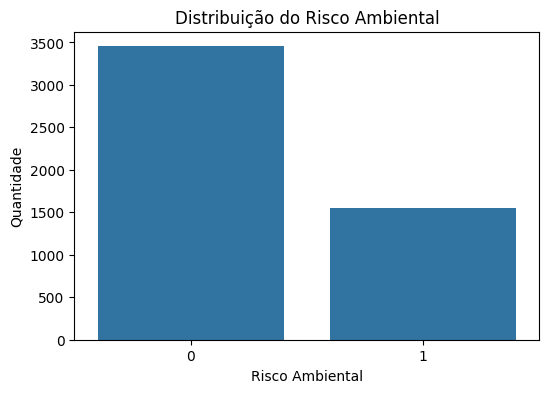

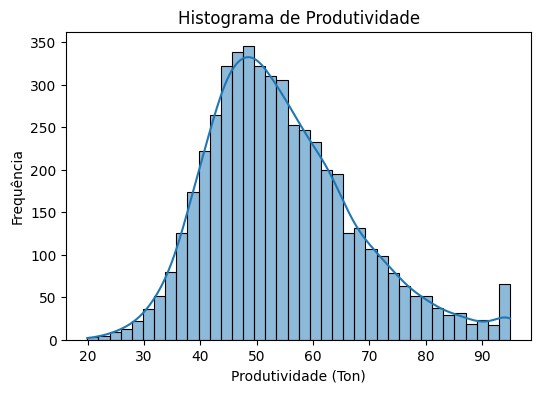

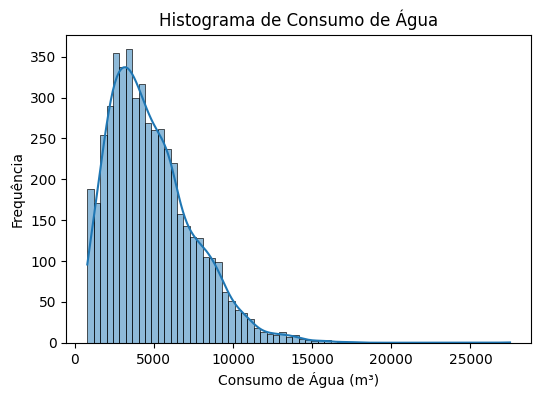

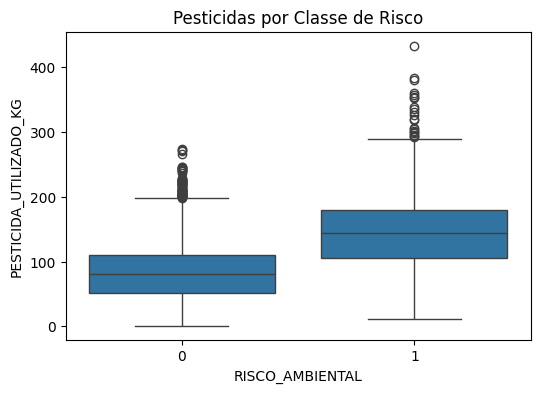

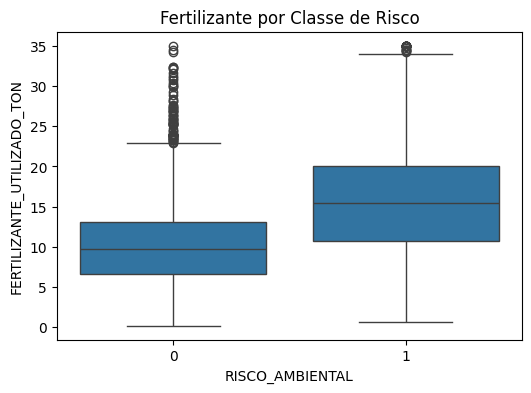

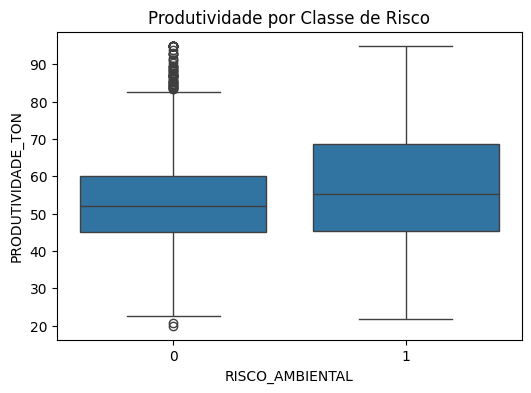

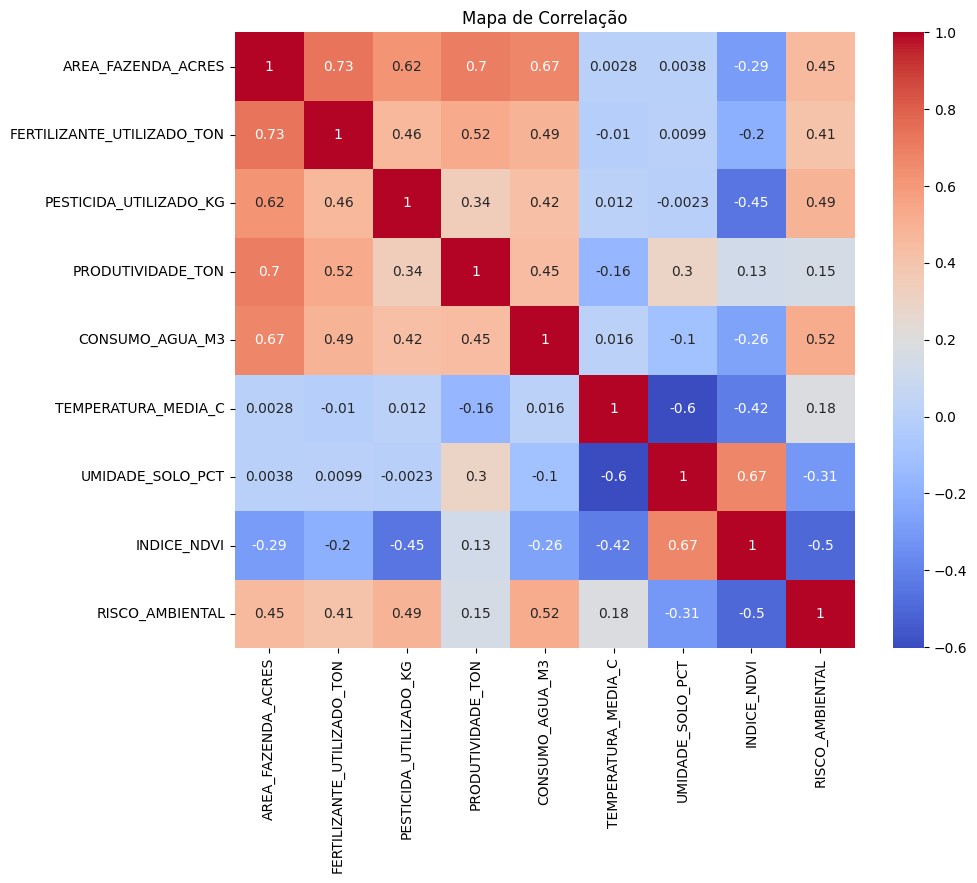

In [3]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='RISCO_AMBIENTAL')
plt.title('Distribuição do Risco Ambiental')
plt.xlabel('Risco Ambiental')
plt.ylabel('Quantidade')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['PRODUTIVIDADE_TON'], kde=True)
plt.title('Histograma de Produtividade')
plt.xlabel('Produtividade (Ton)')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['CONSUMO_AGUA_M3'], kde=True)
plt.title('Histograma de Consumo de Água')
plt.xlabel('Consumo de Água (m³)')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='RISCO_AMBIENTAL', y='PESTICIDA_UTILIZADO_KG')
plt.title('Pesticidas por Classe de Risco')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='RISCO_AMBIENTAL', y='FERTILIZANTE_UTILIZADO_TON')
plt.title('Fertilizante por Classe de Risco')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='RISCO_AMBIENTAL', y='PRODUTIVIDADE_TON')
plt.title('Produtividade por Classe de Risco')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()


### Interpretação Esperada

- Propriedades de alto risco tendem a apresentar maior uso de água, pesticidas e fertilizantes.
- Menor produtividade pode estar associada ao aumento do risco ambiental.
- O heatmap permite identificar relações entre as variáveis agrícolas.


## Etapa 4 - Data Munging

In [4]:

print(df.isnull().sum())

for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(exclude=np.number):
    df[col] = df[col].fillna(df[col].mode()[0])

# Identificação de outliers via IQR
for col in df.select_dtypes(include=np.number).columns:
    if col != 'RISCO_AMBIENTAL':
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        inferior = q1 - 1.5 * iqr
        superior = q3 + 1.5 * iqr

        outliers = ((df[col] < inferior) | (df[col] > superior)).sum()
        print(f'{col}: {outliers} outliers')

# Removendo ID
df = df.drop(columns=['ID_FAZENDA'])


ID_FAZENDA                      0
SATELITE                        0
TIPO_CULTURA                    0
AREA_FAZENDA_ACRES              0
TIPO_IRRIGACAO                  0
TIPO_SOLO                      75
ESTACAO                         0
FERTILIZANTE_UTILIZADO_TON     60
PESTICIDA_UTILIZADO_KG          0
PRODUTIVIDADE_TON               0
CONSUMO_AGUA_M3                 0
TEMPERATURA_MEDIA_C             0
UMIDADE_SOLO_PCT              125
INDICE_NDVI                   100
RISCO_AMBIENTAL                 0
dtype: int64
AREA_FAZENDA_ACRES: 95 outliers
FERTILIZANTE_UTILIZADO_TON: 135 outliers
PESTICIDA_UTILIZADO_KG: 69 outliers
PRODUTIVIDADE_TON: 118 outliers
CONSUMO_AGUA_M3: 89 outliers
TEMPERATURA_MEDIA_C: 24 outliers
UMIDADE_SOLO_PCT: 28 outliers
INDICE_NDVI: 23 outliers


## Etapa 5 - Preparação dos Dados

In [5]:

X = df.drop('RISCO_AMBIENTAL', axis=1)
y = df['RISCO_AMBIENTAL']

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

preprocessador = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Etapa 6 - Treinamento dos Modelos

In [6]:

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'GaussianNB': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

resultados = {}

X_train_proc = preprocessador.fit_transform(X_train)
X_test_proc = preprocessador.transform(X_test)

if hasattr(X_train_proc, "toarray"):
    X_train_dense = X_train_proc.toarray()
    X_test_dense = X_test_proc.toarray()
else:
    X_train_dense = X_train_proc
    X_test_dense = X_test_proc

for nome, modelo in modelos.items():

    if nome == 'GaussianNB':
        modelo.fit(X_train_dense, y_train)
        pred = modelo.predict(X_test_dense)
    else:
        modelo.fit(X_train_proc, y_train)
        pred = modelo.predict(X_test_proc)

    acc = accuracy_score(y_test, pred)

    resultados[nome] = {
        'modelo': modelo,
        'pred': pred,
        'accuracy': acc
    }

    print(f'{nome}: {acc:.4f}')


Logistic Regression: 0.8720
GaussianNB: 0.8530
Random Forest: 0.9130


## Etapa 7 - Avaliação


Logistic Regression


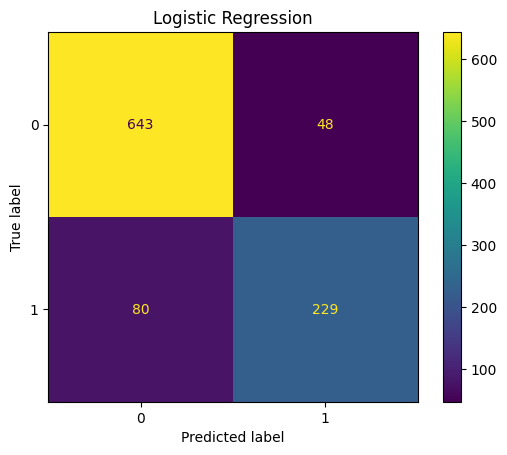

Accuracy: 0.872

GaussianNB


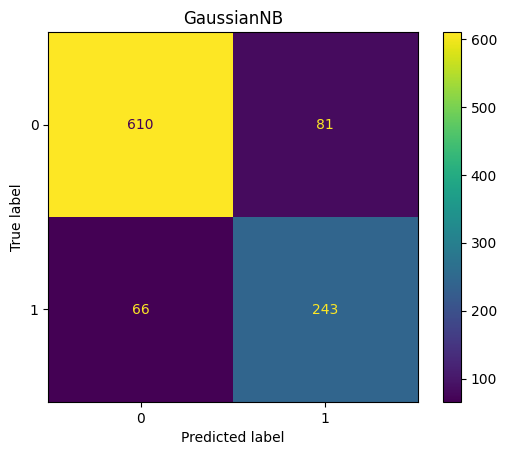

Accuracy: 0.853

Random Forest


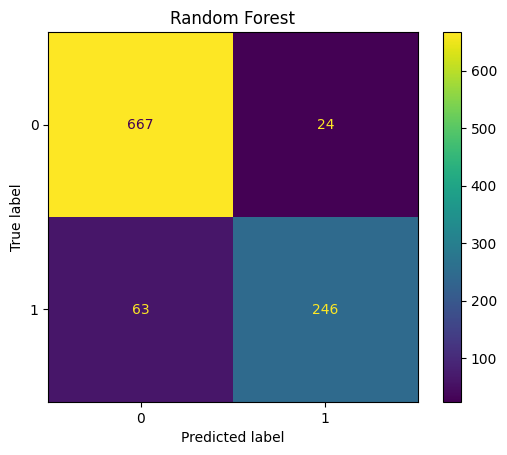

Accuracy: 0.913


In [7]:

for nome, resultado in resultados.items():

    print('\n', '='*50)
    print(nome)
    print('='*50)

    matriz = confusion_matrix(y_test, resultado['pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz
    )

    disp.plot()
    plt.title(nome)
    plt.show()

    print('Accuracy:', round(resultado['accuracy'],4))


### Interpretação Técnica

- Accuracy representa a proporção de classificações corretas.
- A matriz de confusão permite verificar erros entre baixo e alto risco.
- Falsos negativos são críticos, pois propriedades realmente perigosas podem ser classificadas como seguras.


## Etapa 8 - Conclusão Analítica

### Agricultura Inteligente
A Ciência de Dados permite monitorar propriedades agrícolas, prever riscos ambientais e apoiar decisões sustentáveis.

### Sensoriamento Remoto
Satélites e sensores remotos fornecem informações sobre vegetação, umidade do solo e produtividade, possibilitando monitoramento contínuo.

### Impactos Ambientais
O uso excessivo de água, pesticidas e fertilizantes pode causar degradação ambiental, contaminação do solo e desperdício de recursos.

### Riscos de Falsos Negativos
Classificar uma fazenda de alto risco como baixo risco pode impedir ações preventivas e aumentar impactos ambientais.

### Limitações
- Dataset limitado às variáveis disponíveis.
- Possíveis mudanças climáticas não consideradas.
- Dependência da qualidade dos dados.

### Melhorias Futuras
- Inclusão de imagens de satélite.
- Uso de modelos avançados como XGBoost.
- Integração com dados climáticos em tempo real.
